In [1]:
# ─────────────────────────────────────────────────────────────
# CELL 1 ── INSTALL PACKAGES
# ─────────────────────────────────────────────────────────────
print(" Installing packages...")

import subprocess, sys

pkgs = [
    "torch torchvision",
    "opencv-python",
    "numpy pandas matplotlib",
    "ultralytics",
    "scikit-image pillow pyyaml",
    "albumentations",
]
for p in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + p.split(),
                   capture_output=True)

print(" All packages installed!\n")

 Installing packages...
 All packages installed!



In [2]:

# ─────────────────────────────────────────────────────────────
# CELL 2 ── LOCATE DATASET (already extracted on Kaggle)
# ─────────────────────────────────────────────────────────────
import os

data_path = '/kaggle/input/datasets/aditivilaspawar/dataset'

print(" Dataset structure:")
for root, dirs, files in os.walk(data_path):
    level = root.replace(data_path, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:
        for f in files[:3]:
            print(f"  {indent}{f}")

print(" Dataset ready!\n")

 Dataset structure:
dataset/
  dataset/
    WEED/
    WHEAT/
 Dataset ready!



In [3]:
# ─────────────────────────────────────────────────────────────
# CELL 3 ── KAGGLE: LOAD HACKATHON PIPELINE CODE + SET DEVICE
# ⚠️ CHANGE: No files.upload(). Pipeline .py loaded from /kaggle/input/
#
# HOW TO USE:
#   1. Click "+ Add Data" → upload HACKATHON_PIPELINE_BEGINNER.py as a dataset
#   2. Update PY_PATH below to match where Kaggle placed it
#      (e.g. /kaggle/input/hackathon-pipeline/HACKATHON_PIPELINE_BEGINNER.py)
# ─────────────────────────────────────────────────────────────
import torch
import shutil

#  UPDATE THIS PATH to match your Kaggle dataset input path
PY_PATH = '/kaggle/input/datasets/aditivilaspawar/hackathon-pipeline/HACKATHON_PIPELINE_BEGINNER.py'

# Copy to working dir so exec() can find it
shutil.copy(PY_PATH, '/kaggle/working/HACKATHON_PIPELINE_BEGINNER.py')
exec(open('/kaggle/working/HACKATHON_PIPELINE_BEGINNER.py').read())

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"\n✅ Device  : {DEVICE.upper()}")
print(f"✅ GPU     : {torch.cuda.get_device_name(0) if DEVICE=='cuda' else 'N/A'}")
print(f"✅ Classes : SimpleUNet, SmartAgriculturePipeline loaded\n")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✓ All libraries imported successfully!
Using device: CUDA

🌾 INITIALIZING SMART AGRICULTURE PIPELINE 🌾

[*] Initializing Step 1: Crop Detection...
[⚠] No trained model found. Using untrained U-Net for demo.
[*] Initializing Step 2: Decision Logic...
[*] Initializing Step 3: Weed Detection...
[*] Loading YOLOv8 model: yolov8m.pt
[✓] YOLOv8 model loaded successfully!
[*] Initializing Step 4: Report Generator...

[✓] Pipeline initialized successfully!


✓ Pipeline ready! Use: pipeline.process_field_image('image_path') to process a field image

✅ Device  : CUDA
✅ GPU     : Tesla T4
✅ Classes : SimpleUNet, SmartAgriculturePipeline loaded



In [4]:
# ─────────────────────────────────────────────────────────────
# CELL 4 ── MONKEY-PATCH SIMPLEUNET
#   • Remove built-in Sigmoid (we apply it explicitly where needed)
#   • Add BatchNorm for faster convergence
#   • Use BCELoss (model outputs 0-1 via sigmoid — consistent)
# ─────────────────────────────────────────────────────────────
import torch.nn as nn

def conv_block_bn(self, in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )

SimpleUNet.conv_block = conv_block_bn
print(" BatchNorm injected into SimpleUNet")

# Verify forward pass
_t = SimpleUNet()
_x = torch.randn(1, 3, 512, 512)
_y = _t(_x)
assert _y.shape == (1, 1, 512, 512), f"Unexpected shape: {_y.shape}"
assert 0.0 <= _y.min().item() and _y.max().item() <= 1.0, "Sigmoid output expected"
print(f" Forward pass OK: {_x.shape} → {_y.shape}  (values in [0,1])\n")
del _t, _x, _y

 BatchNorm injected into SimpleUNet
 Forward pass OK: torch.Size([1, 3, 512, 512]) → torch.Size([1, 1, 512, 512])  (values in [0,1])



In [5]:
# ─────────────────────────────────────────────────────────────
# CELL 5 ── FIND DATASET IMAGES
# ─────────────────────────────────────────────────────────────
import glob, cv2, numpy as np
from PIL import Image

BASE = '/kaggle/input/datasets/aditivilaspawar/dataset/dataset'

wheat_images = (glob.glob(f'{BASE}/WHEAT/*.jpg') +
                glob.glob(f'{BASE}/WHEAT/*.png'))
weed_images  = (glob.glob(f'{BASE}/WEED/*.jpg')  +
                glob.glob(f'{BASE}/WEED/*.png'))

print(f" Wheat images : {len(wheat_images)}")
print(f" Weed  images : {len(weed_images)}")
print(f" Total        : {len(wheat_images) + len(weed_images)}\n")

 Wheat images : 384
 Weed  images : 306
 Total        : 690



🔧 Generating HIGH-QUALITY masks...
⚠ Weak HSV → fallback for ta-s (69)
⚠ Weak HSV → fallback for ta-s (67)
⚠ Weak HSV → fallback for ta-g1 (47)
⚠ Weak HSV → fallback for ta-s (61)
⚠ Weak HSV → fallback for wheat_0_2019
⚠ Weak HSV → fallback for wheat_0_1182
⚠ Weak HSV → fallback for ta-s (648)
⚠ Weak HSV → fallback for wheat_0_1731
⚠ Weak HSV → fallback for ta-s (68)
⚠ Weak HSV → fallback for ta-s (646)
⚠ Weak HSV → fallback for ta-g1 (51)
⚠ Weak HSV → fallback for ta-s (625)
⚠ Weak HSV → fallback for wheat_0_1189
⚠ Weak HSV → fallback for wheat_0_1167
 Generated 690 high-quality masks


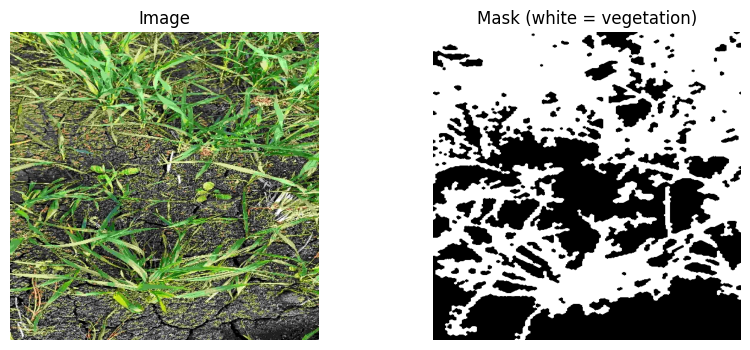

In [6]:
# =====================================================
# CELL 6 — FINAL HIGH-QUALITY MASK GENERATION
# =====================================================

import os, cv2, glob
import numpy as np

img_dir  = '/kaggle/working/unet_dataset/images/'
mask_dir = '/kaggle/working/unet_dataset/masks/'
os.makedirs(img_dir,  exist_ok=True)
os.makedirs(mask_dir, exist_ok=True)

def generate_mask(image_path):
    fname = os.path.splitext(os.path.basename(image_path))[0]

    img = cv2.imread(image_path)
    if img is None:
        print(f"⚠ Skipping corrupted image: {image_path}")
        return False

    # Resize
    img = cv2.resize(img, (512, 512))
    cv2.imwrite(f"{img_dir}/{fname}.jpg", img)

    # Convert to HSV
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # =================================================
    #  STRONG GREEN DETECTION (TIGHT + LOOSE RANGE)
    # =================================================
    lower1 = np.array([25, 40, 40])
    upper1 = np.array([85, 255, 255])

    lower2 = np.array([15, 20, 20])   # captures yellow-green
    upper2 = np.array([100, 255, 255])

    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)

    mask = cv2.bitwise_or(mask1, mask2)

    # =================================================
    #  CLEAN MASK (IMPORTANT)
    # =================================================
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask   = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask   = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # =================================================
    # SMART FALLBACK (MORE AGGRESSIVE)
    # =================================================
    green_ratio = (mask > 0).mean()

    if green_ratio < 0.03:   #  KEY FIX (was too low before)
        print(f"⚠ Weak HSV → fallback for {fname}")

        lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
        a_channel = lab[:, :, 1]

        _, mask = cv2.threshold(
            a_channel, 0, 255,
            cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
        )

        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    # =================================================
    # REMOVE NOISE (VERY IMPORTANT FOR IoU)
    # =================================================
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask)

    clean_mask = np.zeros_like(mask)

    for i in range(1, num_labels):
        area = stats[i, cv2.CC_STAT_AREA]
        if area > 500:   #  removes tiny noise
            clean_mask[labels == i] = 255

    # Save final mask
    cv2.imwrite(f"{mask_dir}/{fname}.png", clean_mask)
    return True


# =====================================================
# GENERATE DATASET
# =====================================================

print("🔧 Generating HIGH-QUALITY masks...")

all_images = wheat_images + weed_images

ok = 0
for img_path in all_images:
    if generate_mask(img_path):
        ok += 1

print(f" Generated {ok} high-quality masks")

# =====================================================
# SANITY CHECK (VERY IMPORTANT)
# =====================================================

import matplotlib.pyplot as plt
import random

sample = random.choice(glob.glob(img_dir + '*.jpg'))

img  = cv2.cvtColor(cv2.imread(sample), cv2.COLOR_BGR2RGB)
mask = cv2.imread(sample.replace('images', 'masks').replace('.jpg', '.png'),
                  cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask (white = vegetation)")
plt.axis('off')

plt.show()

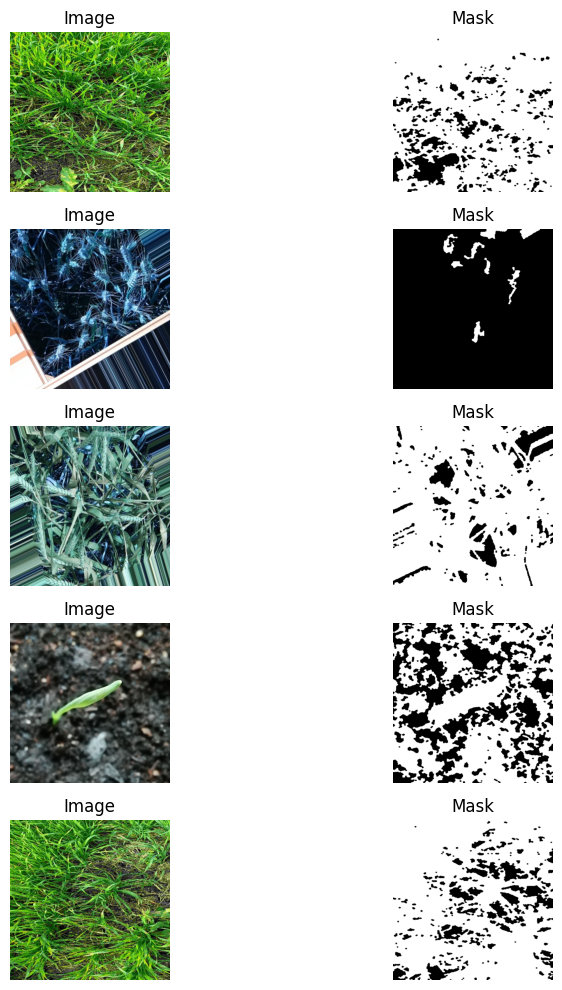

In [7]:
import random
import matplotlib.pyplot as plt
import glob, cv2

samples = random.sample(glob.glob('/kaggle/working/unet_dataset/images/*.jpg'), 5)

plt.figure(figsize=(10,10))

for i, path in enumerate(samples):
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(
        path.replace('images','masks').replace('.jpg','.png'),
        cv2.IMREAD_GRAYSCALE
    )

    plt.subplot(5,2,2*i+1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis('off')

    plt.subplot(5,2,2*i+2)
    plt.imshow(mask, cmap='gray')
    plt.title("Mask")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────────────────────
# CELL 7 ── PYTORCH DATASET + AUGMENTATIONS
# ─────────────────────────────────────────────────────────────
import random, torch
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split

IMG_DIR  = '/kaggle/working/unet_dataset/images/'
MASK_DIR = '/kaggle/working/unet_dataset/masks/'

class WheatWeedDataset(Dataset):
    def __init__(self, img_dir, mask_dir, augment=False):
        self.images = sorted(glob.glob(img_dir  + '*.jpg'))
        self.masks  = sorted(glob.glob(mask_dir + '*.png'))
        assert len(self.images) == len(self.masks), \
            f"Image/mask count mismatch: {len(self.images)} vs {len(self.masks)}"

        if augment:
            self.tf = A.Compose([
                A.RandomCrop(448, 448),
                A.Resize(512, 512),
                A.HorizontalFlip(p=0.5),
                A.VerticalFlip(p=0.3),
                A.RandomRotate90(p=0.5),
                A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.2,
                                   rotate_limit=30, p=0.6),
                A.OneOf([
                    A.ElasticTransform(p=1.0),
                    A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
                ], p=0.4),
                A.OneOf([
                    A.RandomBrightnessContrast(0.3, 0.3, p=1.0),
                    A.HueSaturationValue(15, 30, 20, p=1.0),
                    A.CLAHE(clip_limit=3.0, p=1.0),
                ], p=0.6),
                A.GaussianBlur(blur_limit=(3, 5), p=0.2),
                A.GaussNoise(std_range=(0.02, 0.1), p=0.2),
                A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
                ToTensorV2(),
            ])
        else:
            self.tf = A.Compose([
                A.Resize(512, 512),
                A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
                ToTensorV2(),
            ])

    def __len__(self): return len(self.images)

    def __getitem__(self, idx):
        img  = np.array(Image.open(self.images[idx]).convert('RGB'))
        mask = np.array(Image.open(self.masks[idx]).convert('L'))
        mask = (mask > 127).astype(np.float32)          # binary 0/1
        out  = self.tf(image=img, mask=mask)
        return out['image'], out['mask'].unsqueeze(0)   # (3,512,512), (1,512,512)


class AugWrapper(Dataset):
    """Wraps a random_split subset to apply augmentations."""
    def __init__(self, subset, img_dir, mask_dir):
        self.indices = subset.indices
        self.aug_ds  = WheatWeedDataset(img_dir, mask_dir, augment=True)
    def __len__(self):  return len(self.indices)
    def __getitem__(self, i): return self.aug_ds[self.indices[i]]


full_ds  = WheatWeedDataset(IMG_DIR, MASK_DIR, augment=False)
n_train  = int(0.8 * len(full_ds))
n_val    = len(full_ds) - n_train
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(42))

train_ds = AugWrapper(train_ds, IMG_DIR, MASK_DIR)

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f"✅ Train batches : {len(train_loader)}  ({len(train_ds)} samples)")
print(f"✅ Val   batches : {len(val_loader)}   ({len(val_ds)} samples)\n")

✅ Train batches : 69  (552 samples)
✅ Val   batches : 18   (138 samples)



/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [9]:
# ─────────────────────────────────────────────────────────────
# CELL 8 ── LOSS + METRIC FUNCTIONS
#   Uses BCELoss (model has Sigmoid → outputs 0-1)
#   Dice component handles class imbalance
# ─────────────────────────────────────────────────────────────
import torch.nn as nn

class DiceBCELoss(nn.Module):
    """Combined Dice + BCE loss for segmentation."""
    def __init__(self, smooth=1.0, bce_weight=0.5):
        super().__init__()
        self.bce_w  = bce_weight
        self.smooth = smooth
        self.bce    = nn.BCELoss()   # model outputs sigmoid (0-1) ✓

    def forward(self, pred, target):
        bce  = self.bce(pred, target)
        p, t = pred.view(-1), target.view(-1)
        inter = (p * t).sum()
        dice = 1 - (2*inter + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.bce_w * bce + (1 - self.bce_w) * dice


def iou_score(pred, target, threshold=0.5):
    """Intersection-over-Union. pred must be in [0,1]."""
    p     = (pred  > threshold).float()
    t     = (target > threshold).float()
    inter = (p * t).sum()
    union = p.sum() + t.sum() - inter
    return ((inter + 1e-6) / (union + 1e-6)).item()

In [10]:
# ─────────────────────────────────────────────────────────────
# CELL 9 ── TRAIN U-NET  (50 epochs, cosine LR, grad clip)
# ─────────────────────────────────────────────────────────────
import torch.optim as optim

UNET_SAVE = '/kaggle/working/unet_wheat_weed_trained.pth'
EPOCHS    = 50

unet      = SimpleUNet().to(DEVICE)
optimizer = optim.AdamW(unet.parameters(), lr=3e-4, weight_decay=1e-4)
criterion = DiceBCELoss(bce_weight=0.4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,
                                                  T_max=EPOCHS, eta_min=1e-6)
best_iou  = 0.0

import os

if os.path.exists(UNET_SAVE):
    print("✅ Model already exists — loading & skipping training")
    unet.load_state_dict(torch.load(UNET_SAVE, map_location=DEVICE))
else:
    print("🚀 Training model...")
    
print(f"🚀 Training U-Net on {DEVICE.upper()} for {EPOCHS} epochs\n")
print(f"{'Ep':>4} │ {'TrLoss':>8} │ {'VaLoss':>8} │ {'IoU':>7} │ Save")
print("─" * 44)

for epoch in range(1, EPOCHS + 1):

    # ── train ──────────────────────────────────────────────
    unet.train()
    tr_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        preds  = unet(imgs)
        loss   = criterion(preds, masks)
        loss.backward()
        nn.utils.clip_grad_norm_(unet.parameters(), 1.0)   # prevent exploding gradients
        optimizer.step()
        tr_loss += loss.item()

    # ── validate ───────────────────────────────────────────
    unet.eval()
    va_loss = va_iou = 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            preds    = unet(imgs)
            va_loss += criterion(preds, masks).item()
            va_iou  += iou_score(preds, masks)

    tr_loss /= len(train_loader)
    va_loss /= len(val_loader)
    va_iou  /= len(val_loader)
    scheduler.step()

    saved = va_iou > best_iou
    if saved:
        best_iou = va_iou
        torch.save(unet.state_dict(), UNET_SAVE)

    print(f"{epoch:>4} │ {tr_loss:>8.4f} │ {va_loss:>8.4f} │ "
          f"{va_iou*100:>6.2f}% │ {'💾' if saved else ''}")

print(f"\n U-Net training done!  Best IoU = {best_iou*100:.2f}%")
print(f"   Model saved → {UNET_SAVE}\n")
unet.eval()

🚀 Training model...
🚀 Training U-Net on CUDA for 50 epochs

  Ep │   TrLoss │   VaLoss │     IoU │ Save
────────────────────────────────────────────
   1 │   0.3044 │   0.2113 │  83.15% │ 💾
   2 │   0.2479 │   0.2313 │  77.34% │ 
   3 │   0.2485 │   0.1849 │  83.46% │ 💾
   4 │   0.2258 │   0.1551 │  85.54% │ 💾
   5 │   0.2304 │   0.1585 │  84.56% │ 
   6 │   0.2142 │   0.1585 │  84.72% │ 
   7 │   0.2334 │   0.1723 │  82.44% │ 
   8 │   0.2106 │   0.1705 │  83.08% │ 
   9 │   0.2245 │   0.1562 │  85.03% │ 
  10 │   0.2074 │   0.1684 │  83.50% │ 
  11 │   0.2063 │   0.1509 │  86.07% │ 💾
  12 │   0.1952 │   0.1377 │  88.01% │ 💾
  13 │   0.2087 │   0.1519 │  85.75% │ 
  14 │   0.2044 │   0.1570 │  84.80% │ 
  15 │   0.1976 │   0.1375 │  86.98% │ 
  16 │   0.2008 │   0.1858 │  81.36% │ 
  17 │   0.1915 │   0.1367 │  86.44% │ 
  18 │   0.1917 │   0.1335 │  87.54% │ 
  19 │   0.1942 │   0.1488 │  85.77% │ 
  20 │   0.1869 │   0.1267 │  87.96% │ 
  21 │   0.1948 │   0.1233 │  88.31% │ 💾
  22 

SimpleUNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
  )
  (pool2): MaxPool2d(kernel_si

In [11]:
torch.save(unet.state_dict(), UNET_SAVE)
print(" U-Net model saved!")

 U-Net model saved!


 U-Net  mean IoU  : 85.26%
 Best val IoU     : 88.80%
 Target reached!


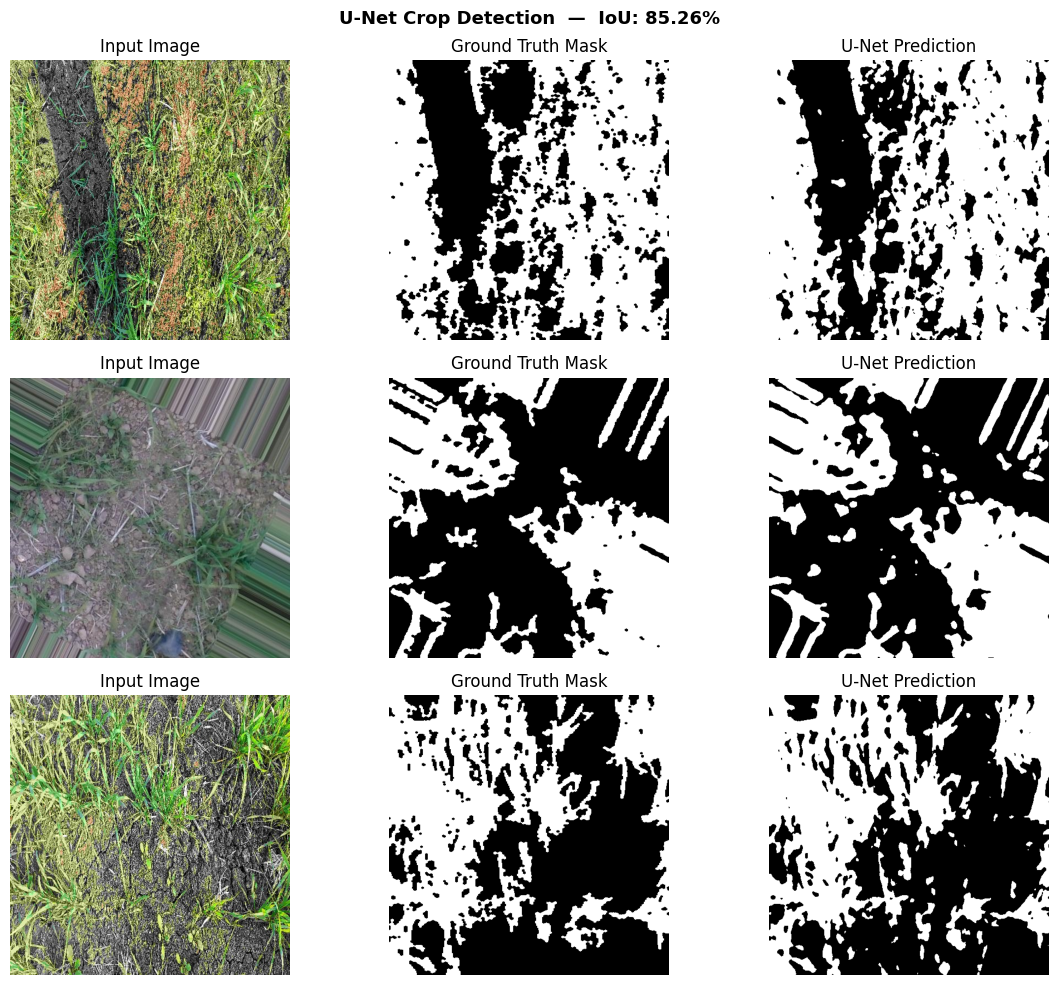

In [12]:
# ─────────────────────────────────────────────────────────────
# CELL 10 ── EVALUATE + VISUALISE U-NET PREDICTIONS
# ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

unet.load_state_dict(torch.load(UNET_SAVE, map_location=DEVICE))
unet.eval()

all_iou = []
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        preds = unet(imgs)
        for p, m in zip(preds, masks):
            all_iou.append(iou_score(p.unsqueeze(0), m.unsqueeze(0)))

mean_iou = np.mean(all_iou) * 100
print(f" U-Net  mean IoU  : {mean_iou:.2f}%")
print(f" Best val IoU     : {best_iou*100:.2f}%")
print(" Target reached!" if mean_iou >= 80 else
      f"⚠  {80-mean_iou:.1f}% below 80% target — try 100 epochs")

# Show 3 predictions
_imgs_b, _masks_b = next(iter(val_loader))
_preds_b = unet(_imgs_b.to(DEVICE)).cpu().detach()
mean_t   = torch.tensor([0.485,0.456,0.406]).view(3,1,1)
std_t    = torch.tensor([0.229,0.224,0.225]).view(3,1,1)

fig, axes = plt.subplots(3, 3, figsize=(12, 10))
for i in range(3):
    img_s  = (_imgs_b[i] * std_t + mean_t).permute(1,2,0).clamp(0,1).numpy()
    msk_s  = _masks_b[i, 0].numpy()
    pred_s = (_preds_b[i, 0] > 0.5).numpy().astype(float)

    axes[i][0].imshow(img_s);             axes[i][0].set_title("Input Image")
    axes[i][1].imshow(msk_s,  cmap='gray'); axes[i][1].set_title("Ground Truth Mask")
    axes[i][2].imshow(pred_s, cmap='gray'); axes[i][2].set_title("U-Net Prediction")
    for ax in axes[i]: ax.axis('off')

plt.suptitle(f"U-Net Crop Detection  —  IoU: {mean_iou:.2f}%", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print()

In [13]:
OUT = '/kaggle/working/wheat_weed_results/'
os.makedirs(OUT, exist_ok=True)

# Models
shutil.copy(UNET_SAVE, OUT + 'unet_wheat_weed_trained.pth')

'/kaggle/working/wheat_weed_results/unet_wheat_weed_trained.pth'